<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Beyond the Fundamental: A Spectral Adventure </b></h3>

**Автор**: Ермекова Асель

*P.S.* *На русском перевод емкого и классного названия не получился у меня. Если у вас есть идеи как назвать эту домашку прикольно, пишите в чатике в телеграме ваши предложения русского варианта названия домашки!*

# **Homework: Beyond the Fundamental: A Spectral Adventure**

## **Introduction**

**Что делает скрипку похожей на скрипку?**

Вы когда-нибудь задумывались, почему скрипка, флейта и гитара звучат совершенно по-разному, даже играя одну и ту же ноту на одинаковой громкости?

Ответ кроется в фундаментальном свойстве звука, называемом тембром. Тембр — это «цвет» или «текстура» звука — то, что позволяет вам мгновенно отличить трубу от фортепиано или голос вашего друга от голоса незнакомца, даже если они поют в одной тональности.

**Но что физически создаёт тембр?**

Всё сводится к гармоникам — смеси частот, сопровождающих основной тон, — и тому, как их амплитуды и фазы изменяются с течением времени. Два инструмента, играющие ноту Ля или А4 (A4 — это нота Ля первой октавы с частотой 440 Гц), оба воспроизводят эту основную частоту, но также генерируют разные наборы обертонов или гармоник (2×440 Гц, 3×440 Гц и т. д.) с уникальной интенсивностью и паттернами. Этот спектральный «отпечаток» называют тембром.

В этом домашнем задании вы станете аудиодетективом. Используя реальные записи разных инструментов, вы:

* Проанализируете их частотные спектры, чтобы увидеть, чем отличаются гармоники,
* Узнаете, почему выбор оконной функции важен при вычислении спектрограмм,
* Реализуете Mel-спектрограмму — представление, имитирующее человеческий слух,
* Обучите простой классификатор распознавать инструменты по их тембру.

Давайте приступим!

Домашнее задание будет состоять из 3 заданий:

* **Task 1.** **Harmonic and Frequency Spectrum Analysis.** Анализ гармонического и частотного спектра различных инструментов.

* **Task 2.** **Windowing in STFT – Why Not Rectangular?** Анализ оконных функций для STFT и почему нам нужны другие формы оконной функции.

* **Task 3.** **Implement Your Own Mel-Spectrogram Transform.** Напишите свою собственную функцию, которая преобразует спектрограмму в мел-спектрограмму и сравнивает с мел-спектрограммой из librosa.

## **Submission Instructions**

- Отправьте **Jupyter Notebook** с:
  - Всем кодом
  - Графиками
  - Ответами на вопросы
- Назовите его: `DLS_HW2_Spectrograms_<ваше_имя>.ipynb`

Домашнее задание будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.

# **Load libraries**

In [132]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

# **Task 1: Harmonic and Frequency Spectrum Analysis** [6 score]

### **Цель**: Понять, как разные инструменты создают разные гармонические структуры для одной и той же высоты звука → это и есть **тембр**.



### **1.1 Load a WAV file** [0.5 score]
- Download file `Vn-ord-A5-pp-1c-N.wav`
- Use `librosa.load(path, sr=None)` to load the audio. Keep the original sampling rate.
- Print the sampling rate and duration.

In [133]:
import os

os.makedirs("content", exist_ok=True)

# Скачиваем файлы в папку content
# !gdown 1JOFNfzNzV5RTDv6YBFZ0lKZRfyoukW7O -O content/Vn-ord-A5-pp-1c-N.wav
# !gdown 19RVoksj40dds4lfSiha17HuTLYCFvwCs -O content/Vc-ord-A5-pp-1c-N.wav
# !gdown 1gVMlgMg9wGyPGRIbu7e_Q67JfzU0Rn1E -O content/Acc-ord-A5-pp-N-N.wav
# !gdown 1gstlGhDe7SYEMpHQV6N50zb8TPByL2gI -O content/Fl-ord-A5-pp-N-N.wav
# !gdown --folder 1wMa4fDtWRtO-YAz-gY5Jdrl94GQZUwmO -O content/TinySOL_short

In [134]:
# !gdown 1JOFNfzNzV5RTDv6YBFZ0lKZRfyoukW7O # download violin playing A5: Vn-ord-A5-pp-1c-N.wav

In [135]:
# Example: Load violin A5
audio_path = 'content/Vn-ord-A5-pp-1c-N.wav'
y, sr = librosa.load(audio_path, sr=None)

print(f'Sampling rate: {sr} Hz')
print(f'Duration: {len(y)/sr:.2f} seconds')

Sampling rate: 44100 Hz
Duration: 7.93 seconds


In [136]:
from IPython.display import Audio

display(Audio(data=y, rate=sr))

### **1.2 Compute the Fourier Transform and plot the magnitude spectrum** [1 score]
- Compute the FFT of the entire audio signal. Use `np.fft.rfft` and `np.fft.rfftfreq`.
- Compute absolute values of the magnitude with `np.abs()` and normalize it.
- Plot the magnitude spectrum (only up to Nyquist frequency).
- Label axes: frequency (Hz) vs magnitude.

> 💡 **Tip**: Normalize magnitude by dividing by `len(signal)`.

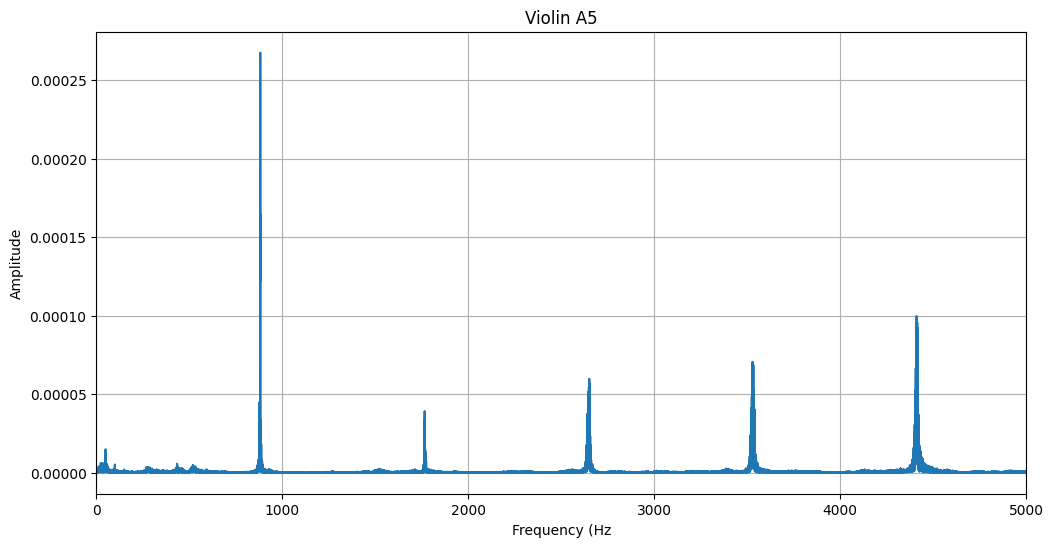

In [137]:
# Compute FFT
fft_result = np.fft.rfft(y)
freqs = np.fft.rfftfreq(len(y), 1/sr)

# Magnitude
magnitude = np.abs(fft_result) / len(y)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(freqs, magnitude)
plt.xlim(0, 5000)
plt.title('Violin A5')
plt.xlabel('Frequency (Hz')
plt.ylabel('Amplitude')
plt.grid(True)

plt.show();

### **1.3 Identify and plot harmonics** [0.5 score]
- Find the **fundamental frequency** (f₀) corresponding to the pitch of A5 note (for example, the fundamental frequency for the note A4 is 440 Hz.).
- Calculate harmonics f₀, 2f₀, 3f₀, ..., up to 5000 Hz.
- Plot harmonics as vertical dashed lines and annotate them (e.g., "1st harmonic", "2nd harmonic").

> 📌 **Hint**: You can get theoretical f₀ from `librosa.note_to_hz('A4')`.

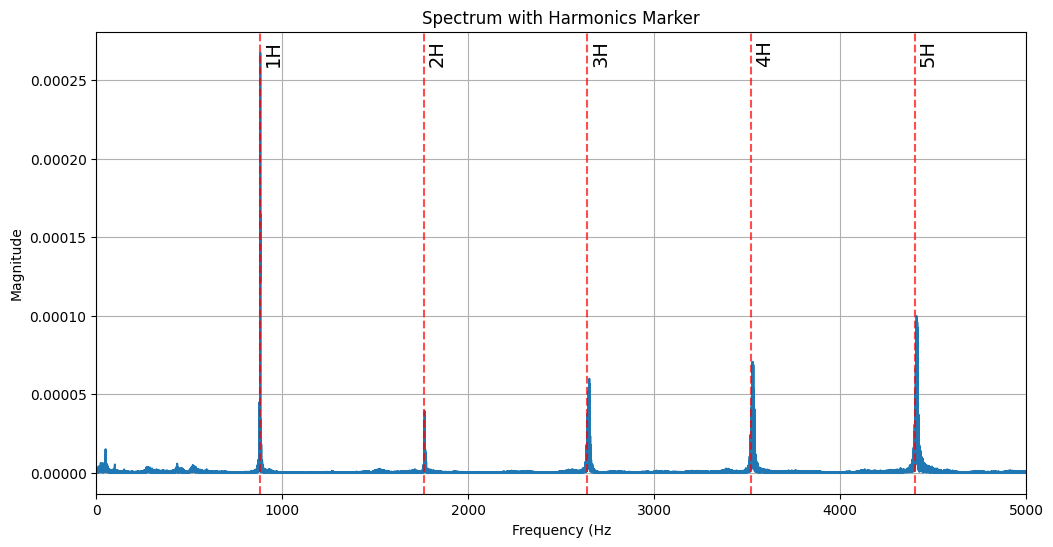

In [138]:
f0 = librosa.note_to_hz('A5')
max_freq = 5000
harmonics = []
n = 1
while n * f0 <= max_freq:
    harmonics.append(n * f0)
    n += 1

# Plot with harmonics marked
plt.figure(figsize=(12, 6))
plt.plot(freqs, magnitude)
plt.xlim(0, max_freq)
plt.title('Spectrum with Harmonics Marker')
plt.xlabel('Frequency (Hz')
plt.ylabel('Magnitude')
plt.grid(True)

# Гармоники
for i, h in enumerate(harmonics, 1):
    plt.axvline(x=h, color='red', linestyle='--', alpha=0.7)
    label = f'{i}H'
    plt.text(h + 20, plt.ylim()[1] * 0.93, label, rotation=90, fontsize=14)

plt.show();

### **1.4 Answer: What is the fundamental frequency? What are the amplitudes of the 2nd, 3rd, and 5th harmonics?** [1 score]
- What is the fundamental frequency?
- What are the amplitudes of the 2nd, 3rd, and 5th harmonics?
- Report numerical values (in Hz and amplitude).
- Is the strongest peak always at f₀?

In [139]:
f0 = librosa.note_to_hz('A5')

# Find peaks near harmonic frequencies
def get_harmonic_amplitude(freq, spectrum, freqs):
    idx = np.argmin(np.abs(freqs - freq))
    return spectrum[idx]

fundamental_amp = get_harmonic_amplitude(f0, magnitude, freqs)
second_harm_amp = get_harmonic_amplitude(2*f0, magnitude, freqs)
third_harm_amp = get_harmonic_amplitude(3*f0, magnitude, freqs)
fifth_harm_amp = get_harmonic_amplitude(5*f0, magnitude, freqs)

print(f"Fundamental frequency (f0): {f0:.1f} Hz")
print(f"Fundamental amplitude: {fundamental_amp:.6f}")
print(f"2nd harmonic amplitude: {second_harm_amp:.6f}")
print(f"3rd harmonic amplitude: {third_harm_amp:.6f}")
print(f"5th harmonic amplitude: {fifth_harm_amp:.6f}")

Fundamental frequency (f0): 880.0 Hz
Fundamental amplitude: 0.000003
2nd harmonic amplitude: 0.000002
3rd harmonic amplitude: 0.000020
5th harmonic amplitude: 0.000007


- Основная частота ноты A5 составляет 880 Гц

- Гармоники второй, третьей и пятой гармоник имеют амплитуды:
   - 2-я (1760 Гц): 0.000002
   - 3-я (2640 Гц): 0.00002
   - 5-я (4400 Гц): 0.000007
- Из представленных инструментов (Аккордеон, Виолончель, Флейта, Скрипка) у Виолончели самый сильный пик приходится на гармонику, а не на основную частоту <br>
(по результатам задания 1.5).

### **1.5 Repeat for another instruments playing the same pitch** [1 score]
- Choose a different instruments.
- Repeat steps 1.1–1.3.

In [140]:
# !gdown 19RVoksj40dds4lfSiha17HuTLYCFvwCs # Cello: Vc-ord-A5-pp-1c-N.wav
# !gdown 1gVMlgMg9wGyPGRIbu7e_Q67JfzU0Rn1E # Accordion: Acc-ord-A5-pp-N-N.wav
# !gdown 1gstlGhDe7SYEMpHQV6N50zb8TPByL2gI # Flute: Fl-ord-A5-pp-N-N.wav

In [141]:
database = {'Accordion': 'Acc-ord-A5-pp-N-N.wav',
            'Cello': 'Vc-ord-A5-pp-1c-N.wav',
            'Flute': 'Fl-ord-A5-pp-N-N.wav',
            'Violin': 'Vn-ord-A5-pp-1c-N.wav'}

Гармоники: (1, 880.0) (2, 1760.0) (3, 2640.0) (4, 3520.0) (5, 4400.0)


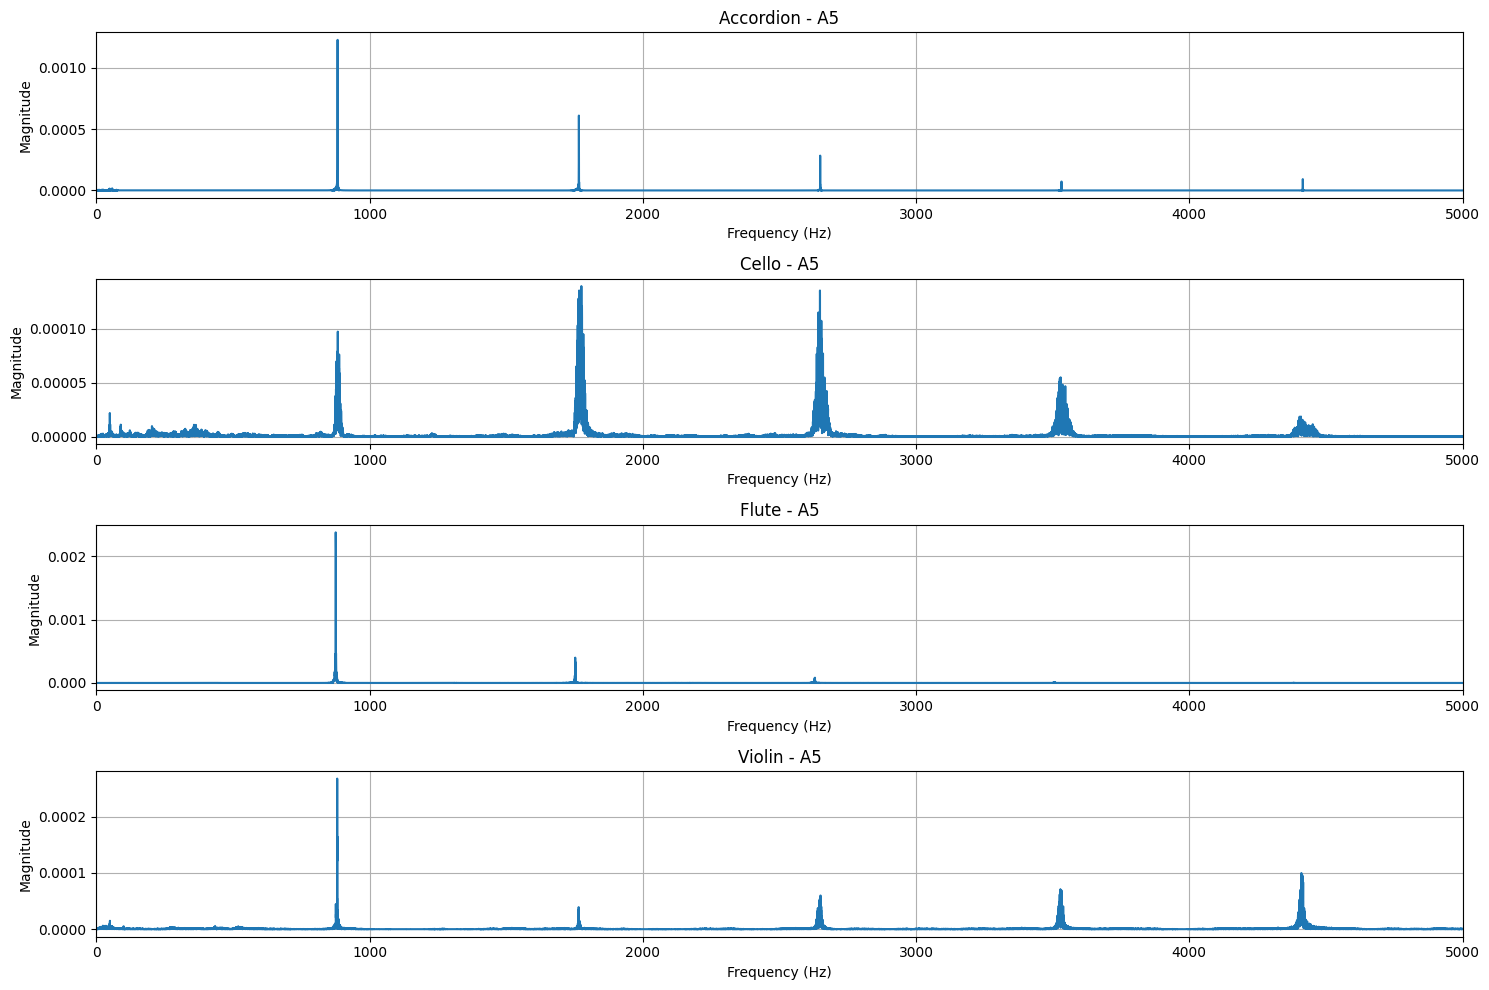

In [142]:
instruments_to_compare = ['Accordion', 'Cello', 'Flute', 'Violin']
plt.figure(figsize=(15, 10))


f0 = librosa.note_to_hz('A5')
max_freq = 5000
harmonics = []
n = 1
while n * f0 <= max_freq:
    harmonics.append(n * f0)
    n += 1

print('Гармоники:', *enumerate(harmonics, 1))

for i, inst in enumerate(instruments_to_compare):

    path_to_wav = os.path.join('content', database[inst])
    y_inst, sr_inst = librosa.load(path_to_wav, sr=None)

    # Compute FFT
    Y_inst = np.fft.rfft(y_inst)
    # Get frequencies
    freqs_inst = np.fft.rfftfreq(len(y_inst), 1/sr_inst)
    # Extract magnitude and normalize it
    magnitude_inst = np.abs(Y_inst) / len(y_inst)

    plt.subplot(4, 1, i+1)
    plt.plot(freqs_inst, magnitude_inst)
    plt.xlim(0, 5000)
    plt.title(f'{inst.capitalize()} - A5')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)

    # Гармоники
    # for i, h in enumerate(harmonics, 1):
    #     plt.axvline(x=h, color='red', linestyle='--', alpha=0.7)
    #     label = f'{i}H'
    #     plt.text(h + 20, plt.ylim()[1] * 0.85, label, rotation=90, fontsize=12)

plt.tight_layout()

plt.show();

Analysis:
- Violin: rich in high harmonics, complex spectrum
- Flute: mostly fundamental, few weak harmonics
- Guitar: strong fundamental and lower harmonics, decaying higher harmonics
This difference in harmonic content IS timbre!

- **Compare** the two spectra (Violin and another instrument):
  - Are the harmonic amplitudes similar?
  - Which instrument has more high-frequency harmonics?
  - How does this relate to timbre?

- Виолончель имеет спектр, похожий на скрипку, но с более быстрым затуханием высоких гармоник.
- Инструменты с большим количеством высокочастотных гармоник: скрипка, аккордеон.
- Гармоники создают придают уникальный темб музыкальному инструменту. Пронзительнее звучат инструменты с большим количеством высокочастотных гармоник звучат.<br> 
Инструменты с быстрым затуханием гармоник (виолончель, флейта) звучат мягче.

### **1.6 Count significant harmonics** [1 score]
- Define a "significant harmonic" as one with amplitude > 10% of the max amplitude.
- For **Flute** and **Violin** (same pitch), count how many significant harmonics each has.
- Which instrument is "brighter"? Why?

In [143]:
def count_significant_harmonics(magnitude, freqs, f0, max_freq=5000, threshold_ratio=0.1):
    freq_diff = 10
    threshold = np.max(magnitude) * threshold_ratio
    harmonics = []

    n = 1
    while n * f0 <= max_freq:
        target_freq = n * f0

        # Условие выбора гармоники
        mask = (freqs >= target_freq - freq_diff) & (freqs <= target_freq + freq_diff)

        if np.any(mask):
            amp = np.max(magnitude[mask])
            if amp > threshold:
                harmonics.append(target_freq)
        n += 1
    return len(harmonics), harmonics

# Compare Flute and violin
for inst in ['Flute', 'Violin']:
    path_to_wav = os.path.join('content', database[inst])
    y_inst, sr_inst = librosa.load(path_to_wav, sr=None)
    # Compute FFT
    Y_inst = np.fft.rfft(y_inst)
    # Get frequencies
    freqs_inst = np.fft.rfftfreq(len(y_inst), 1/sr_inst)
    # Extract magnitude and normalize it
    magnitude_inst = np.abs(Y_inst) / len(y_inst)

    count, harm_list = count_significant_harmonics(magnitude_inst, freqs_inst, f0)
    print(f'{inst.capitalize()}: {count} significant harmonics')

Flute: 2 significant harmonics
Violin: 5 significant harmonics


Скрипка ярче флейты, потому что у скрипки присутствует больше значимых высокочастотных гармоник.

### **1.7. Simple Instrument Classification** [2 score]
- Use dataset `TinySOL_short` provided below with 3 instruments of the **same pitch** A5.
- **Approach A**: Use raw audio waveforms (flattened) as features → train a Random Forest.
- **Approach B**: Use magnitude spectrum (first 1024 bins) as features → train same model.
- Compare accuracy on a test set.
- **Question**: Why does Approach B perform better?

> 🛠️ Use `sklearn.tree.RandomForestClassifier` and `train_test_split`.

First, download dataset.

In [144]:
# !gdown --folder 1wMa4fDtWRtO-YAz-gY5Jdrl94GQZUwmO -O content/TinySOL_short

In [145]:
df = pd.read_csv('content\TinySOL_short\TinySOL_short.csv')

In [146]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Prepare data for 3 instruments, same pitch (A5)
instruments_class = ['Violin', 'Flute', 'Cello']
X_wave = []
X_spec = []
y_labels = []

max_len = 40000

for idx, row in df.iterrows():
    audio_path = os.path.join('content', row['Path'])
    y_audio, sr_audio = librosa.load(audio_path, sr=None)    

    # raw audio waveforms
    if len(y_audio) < max_len:
        y_padded = np.pad(y_audio, (0, max_len - len(y_audio)), 'constant')
    else:
        y_padded = y_audio[:max_len]
    X_wave.append(y_padded)
    
    # magnitude spectrum
    Y_spec = np.fft.rfft(y_audio)
    mag_spec = np.abs(Y_spec) / len(y_audio)
    X_spec.append(mag_spec[:1024])

    y_labels.append(row['Instrument (in full)'])
    
# Split data
X_wave_train, X_wave_test, y_train, y_test = train_test_split(
    X_wave, y_labels, test_size=0.3, random_state=42, stratify=y_labels
)

X_spec_train, X_spec_test, _, _ = train_test_split(
    X_spec, y_labels, test_size=0.3, random_state=42, stratify=y_labels
)

# Train classifiers

# raw audio waveforms
clf_wave = RandomForestClassifier(n_estimators=100, random_state=42)
clf_wave.fit(X_wave_train, y_train)

# magnitude spectrum
clf_spec = RandomForestClassifier(n_estimators=100, random_state=42)
clf_spec.fit(X_spec_train, y_train)


# Evaluate
acc_wave = accuracy_score(y_test, clf_wave.predict(X_wave_test))
acc_spec = accuracy_score(y_test, clf_spec.predict(X_spec_test))

print(f"Accuracy with raw waveforms: {acc_wave:.3f}")
print(f"Accuracy with spectra: {acc_spec:.3f}")

Accuracy with raw waveforms: 0.600
Accuracy with spectra: 0.800


**Answer**: Подход со спектром амплитуд лучше подхода с сырыми сигналами, так как он менее зависим от фазовых сдвигов и флуктуации амплитуд.<br> 
Метод выделяет более значимые признаки, что способствует лучшему разделению классов.

# **Task 2: Windowing in STFT – Why Not Rectangular?** [10 score]

### **Goal**: Understand spectral leakage and why smooth windows (e.g., Hann) are preferred.

### **2.1 Load a pure sine wave** [0.5 score]
- Generate a 440 Hz sine wave, 1 second long, at 22050 Hz sampling rate.
- Plot the waveform.

$$y = \sin(2 \pi ft)$$

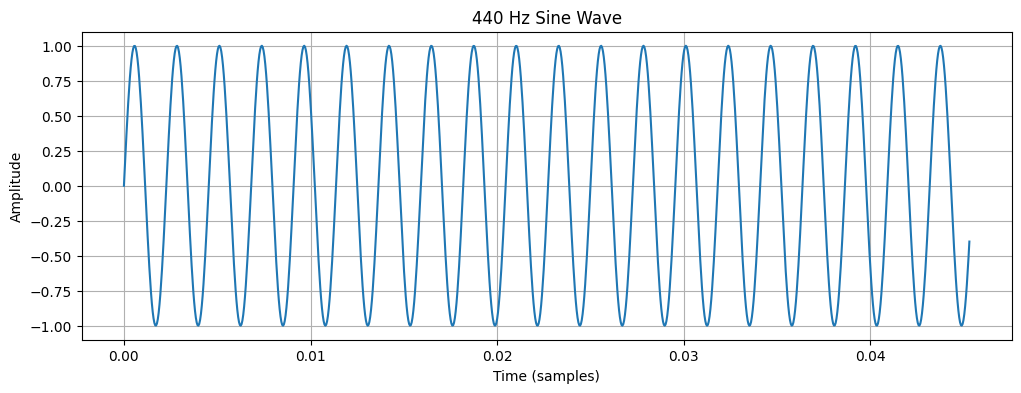

In [147]:
sr = 22050
duration = 1.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
f0 = 440
sine_wave = np.sin(2 * np.pi * f0 * t)

# Plot waveform and Show first 1000 samples
plt.figure(figsize=(12, 4))
plt.plot(t[:1000], sine_wave[:1000])
plt.title('440 Hz Sine Wave')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.show();

### **2.2 Compute STFT with rectangular window** [1 score]
- Use `scipy.signal.stft` with `window='boxcar'` (rectangular), `nperseg=1024`, `noverlap=512`.
- Plot the spectrogram (use `plt.pcolormesh` with dB scale).

> 💡 Convert to dB: `10 * np.log10(np.abs(Zxx) + 1e-10)`

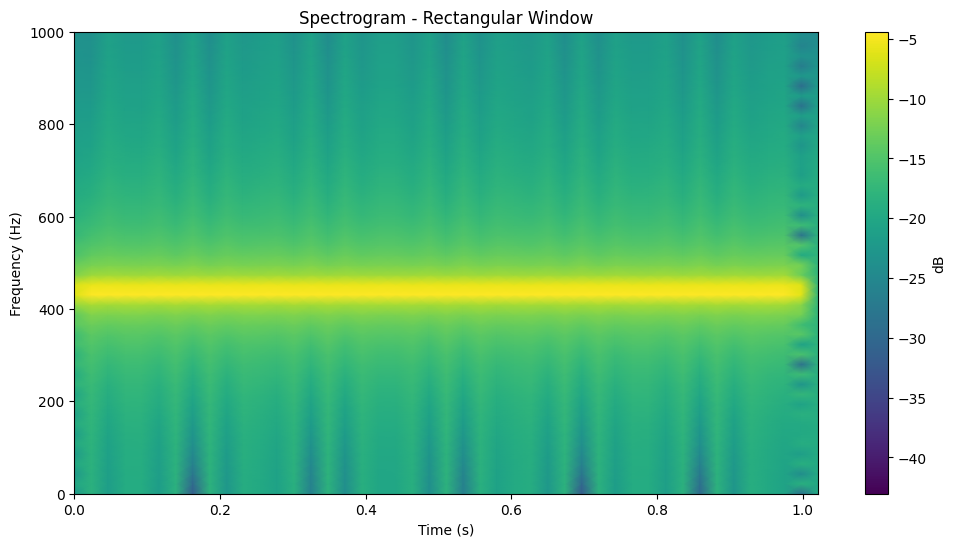

In [148]:
from scipy.signal import stft

# Compute STFT with rectangular window
f_rec, t_rec, Zxx_rec = stft(sine_wave, fs=sr, window='boxcar', nperseg=1024, noverlap=512)

# Plot spectrogram
plt.figure(figsize=(12, 6))
plt.pcolormesh(t_rec, f_rec, 10 * np.log10(np.abs(Zxx_rec) + 1e-10), shading='gouraud')
plt.colorbar(label='dB')
plt.title('Spectrogram - Rectangular Window')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(0, 1000)

plt.show();

### **2.3 Compute STFT with Hann window** [1 score]
- Repeat with `window='hann'`.
- Plot the spectrogram.

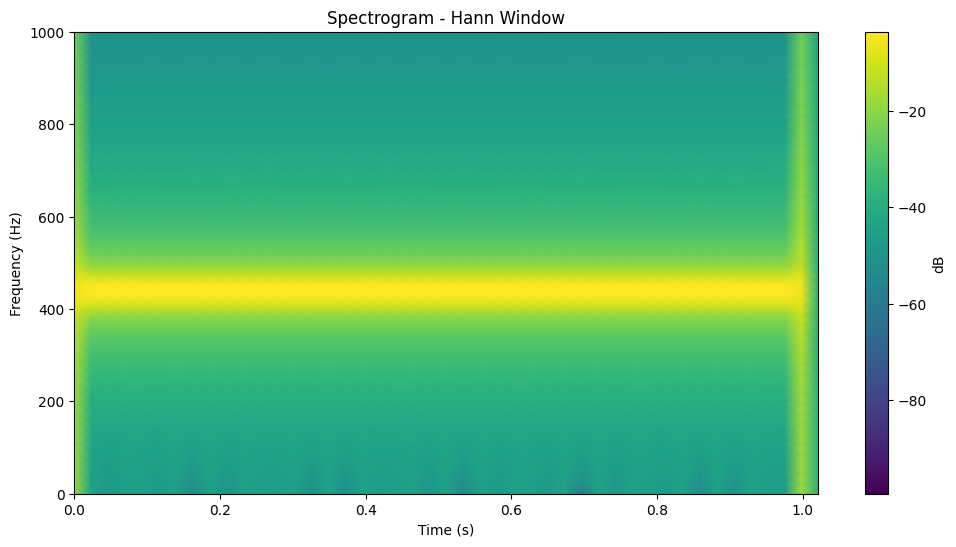

In [149]:
# Compute STFT with hann window
f_hann, t_hann, Zxx_hann = stft(sine_wave, fs=sr, window='hann', nperseg=1024, noverlap=512)

# Plot spectrogram
plt.figure(figsize=(12, 6))
plt.pcolormesh(t_hann, f_hann, 10 * np.log10(np.abs(Zxx_hann) + 1e-10), shading='gouraud')
plt.colorbar(label='dB')
plt.title('Spectrogram - Hann Window')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(0, 1000)

plt.show();

### **2.4 Compare the two spectrograms** [1.5 score]
- **Question**: In the rectangular case, do you see energy at frequencies **other than 440 Hz**? [0.5 score]
- **Question**: Is the main lobe wider or narrower with Hann? [0.5 score]
- **Question**: Which window shows cleaner, more focused energy at 440 Hz? [0.5 score]

Answers to questions:

- В спектрограмме с прямоугольным окном видна энергия на частотах, отличных от 440 Гц.
- Основная лепестковая область шире при использовании окна Ханна.
- Окно Ханна показывает более чистую и сфокусированную энергию на 440 Гц.

### **2.5 Try a signal with two close frequencies** [2 score]
- Generate two sine waves: 440 Hz and 460 Hz.
- Repeat 2.2 and 2.3.
- **Question**: Can you distinguish the two tones with rectangular window? With Hann?


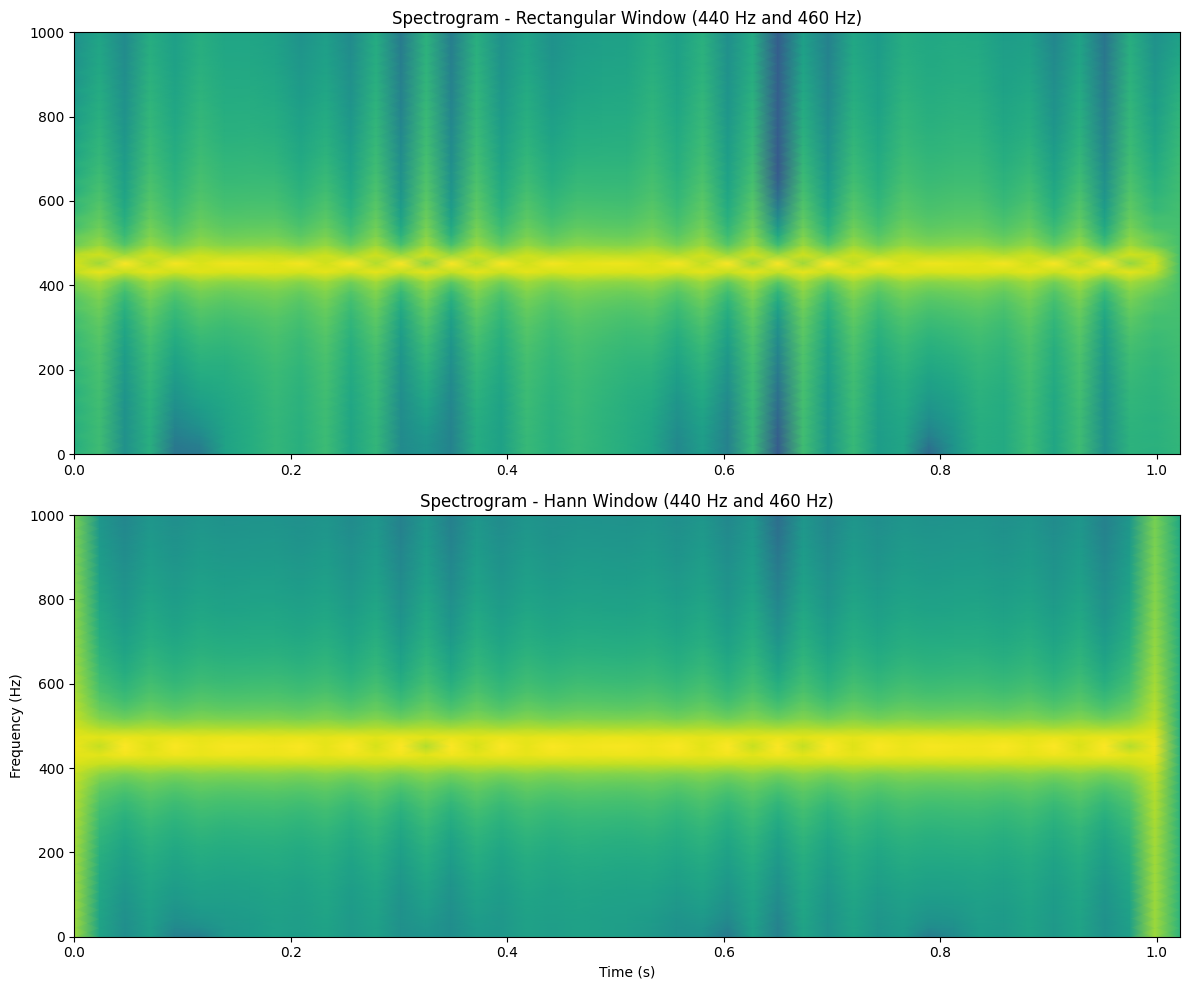

In [150]:
sr = 22050
duration = 1.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

f1 = 440
f2 = 460
sine_wave_1 = np.sin(2 * np.pi * f1 * t)
sine_wave_2 = np.sin(2 * np.pi * f2 * t)
sine_wave_dual = sine_wave_1 + sine_wave_2

f_rec2, t_rec2, Zxx_rec2 = stft(sine_wave_dual, fs=sr, window='boxcar', nperseg=1024, noverlap=512)

f_hann2, t_hann2, Zxx_hann2 = stft(sine_wave_dual, fs=sr, window='hann', nperseg=1024, noverlap=512)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.pcolormesh(t_rec2, f_rec2, 10 * np.log10(np.abs(Zxx_rec2) + 1e-10), shading='gouraud')
ax1.set_title('Spectrogram - Rectangular Window (440 Hz and 460 Hz)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Frequency (Hz)')
ax1.set_ylim(0, 1000)

ax2.pcolormesh(t_hann2, f_hann2, 10 * np.log10(np.abs(Zxx_hann2) + 1e-10), shading='gouraud')
ax2.set_title('Spectrogram - Hann Window (440 Hz and 460 Hz)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Frequency (Hz)')
ax2.set_ylim(0, 1000)

plt.tight_layout()

plt.show();

**Answer**: С прямоугольным окном два тона практически неразличимы. С окном Ханна два тона хорошо различимы.

### **2.6 Analyze a real instrument note** [1 score]
- Load a flute note (A5).
- Compute spectrograms with rectangular and Hann windows.
- **Question**: Does rectangular window create "smearing" or artificial frequencies? [0.5 score]
- **Question**: Which spectrogram better reflects the true harmonic structure? [0.5 score]

In [151]:
# Load flute note A5
row = df[(df['Instrument (in full)'] == 'Flute') & (df['Pitch'] == 'A5')].iloc[0]
y_inst, sr_inst = librosa.load(os.path.join('content', row['Path']), sr=None)

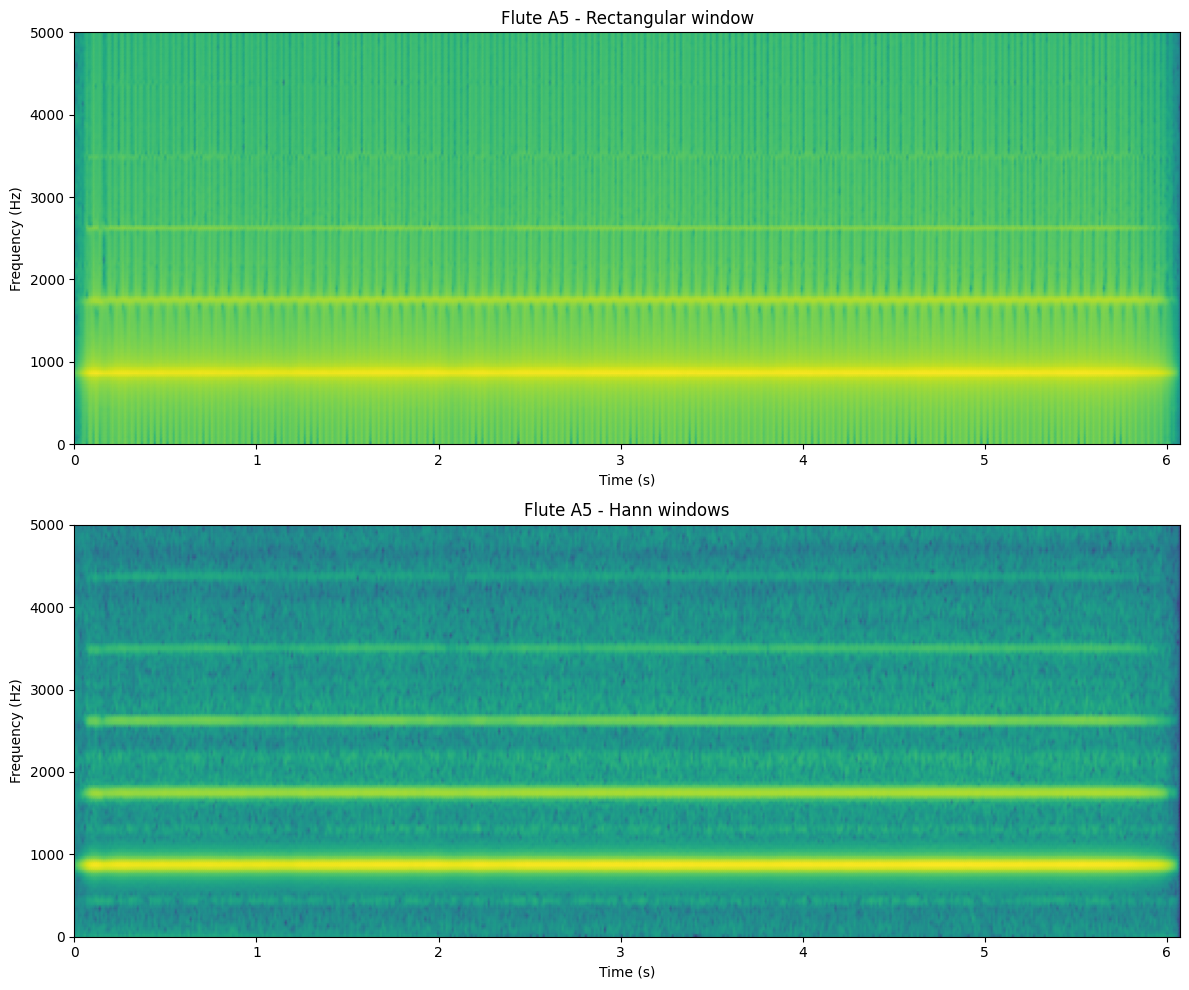

In [152]:
# Compute STFT with rectangular and hann window
f_inst_rec, t_inst_rec, Zxx_inst_rec = stft(y_inst, fs=sr_inst, window='boxcar', nperseg=1024, noverlap=512)
f_inst_hann, t_inst_hann, Zxx_inst_hann = stft(y_inst, fs=sr_inst, window='hann', nperseg=1024, noverlap=512)

# Plot spectrograms
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.pcolormesh(t_inst_rec, f_inst_rec, 10 * np.log10(np.abs(Zxx_inst_rec) + 1e-10), shading='gouraud')
ax1.set_title('Flute A5 - Rectangular window')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Frequency (Hz)')
ax1.set_ylim(0, 5000)

ax2.pcolormesh(t_inst_hann, f_inst_hann, 10 * np.log10(np.abs(Zxx_inst_hann) + 1e-10), shading='gouraud')
ax2.set_title('Flute A5 - Hann windows')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Frequency (Hz)')
ax2.set_ylim(0, 5000)

plt.tight_layout()

plt.show();

**Answer**:
- Прямоугольное окно создает значительное "размазывание" энергии и искусственные частоты. <br>
Энергия как бы размазывается по соседним частотам.
- Спектрограмма с окном Ханна значительно лучше отражает истинную гармоническую структуру. <br>
Гармоники довольно четко разделимы.

### **2.7 Conclusion** [3 score]
- Write 3–4 sentences explaining:
  - What is **spectral leakage**?
  - Why does rectangular window cause it?
  - Why is a smooth (bell-shaped) window better for audio analysis?

**Answer**:
  - Спектральная утечка - это явления, когда энергия сигнала одной частоты размазывается по соседним частотам при преобразовании Фурье.
  - Прямоугольное окно имеет резкие границы, из-за которых имеется разрыв в сигнале. В местах разрыва сигнала появляются высокочастотные области.
  - Гладкое (колоколообразное) окно лучше для анализа аудио, потому что они не имеют таких резких границ окна (как у прямоугольного). <br>
  Соответсвенно спектральная утечка значительно ниже, а гармоники лучше различимы.

# **Task 3: Implement Your Own Mel-Spectrogram Transform** [5 score]

### **Goal**: Understand how Mel-scale warping works by implementing it manually.

### **3.1 Load an audio file** [0.5 score]
- Pick any `.wav` from the dataset.
- Load with `librosa.load(..., sr=22050)`.

In [153]:
# Load audio
sample = df.iloc[0]
y, sr = librosa.load(os.path.join('content', sample['Path']), sr=22050)

### **3.2 Compute STFT** [0.5 score]
- Use `librosa.stft` with `n_fft=2048`, `hop_length=512`, `window='hann'`.
- Compute power spectrogram: `S = np.abs(stft_result) ** 2`.

In [154]:
# Compute STFT
n_fft = 2048
hop_length = 512
window='hann'

# STFT
stft_result = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')

# Power spectrogram
S = np.abs(stft_result) ** 2

print(S.shape)

(1025, 319)


### **3.3 Create Mel filterbank manually** [2 score]
- Number of Mel bands: `n_mels = 128`.
- Frequency range: 0 to `sr/2`.
- Steps:
  1. Convert Hz to Mel: `mel = 2595 * np.log10(1 + f / 700)`
  2. Create `n_mels + 2` equally spaced points in Mel scale.
  3. Convert back to Hz.
  4. Build triangular filters (each filter overlaps with neighbors).
- Output: a matrix `mel_basis` of shape `(n_mels, n_fft//2 + 1)`.

> 📚 Reference: [Librosa mel filterbank docs](https://librosa.org/doc/main/generated/librosa.filters.mel.html)

In [155]:
def hz_to_mel(frequencies):
    """Convert Hz to Mel scale"""
    return 2595 * np.log10(1 + frequencies / 700)

def mel_to_hz(mels):
    """Convert Mel to Hz scale"""
    return 700 * (10 ** (mels / 2595) - 1)

def create_mel_filterbank(sr, n_fft, n_mels=128, fmin=0.0, fmax=None):
    """Create Mel filterbank manually"""

    # Frequency bins
    n_freqs = n_fft // 2 + 1
    linear_freqs = np.linspace(0, sr / 2, n_freqs)

    if fmax is None:
        fmax = sr / 2

    # Mel points
    min_mel = hz_to_mel(fmin)
    max_mel = hz_to_mel(fmax)
    mel_points = np.linspace(min_mel, max_mel, n_mels + 2)
    hz_points = mel_to_hz(mel_points)

    # Create filterbank
    filterbank = np.zeros((n_mels, n_freqs))

    for m in range(n_mels):
        # Triangle vertices
        left = hz_points[m]
        center = hz_points[m + 1]
        right = hz_points[m + 2]

        for i, freq in enumerate(linear_freqs):
            if freq < left or freq > right:
                filterbank[m, i] = 0
            elif freq <= center:
                # На возрастание
                filterbank[m, i] = (freq - left) / (center - left)
            else:
                # На убывание
                filterbank[m, i] = (right - freq) / (right - center)

    return filterbank

# Create filterbank
mel_basis_manual = create_mel_filterbank(sr, n_fft, n_mels=128)

print(mel_basis_manual.shape)

(128, 1025)


### **3.4 Apply filterbank to power spectrogram** [0.5 score]
- Compute: `mel_spec_manual = np.dot(mel_basis, S)`

In [156]:
# Apply manual filterbank
mel_spec_manual = np.dot(mel_basis_manual, S)

print(mel_spec_manual.shape)

(128, 319)


### **3.5 Compute Mel-spectrogram using librosa** [0.5 score]
- Use `librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, hop_length=512, n_mels=128)`

In [157]:
# Librosa version
mel_spec_librosa = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)

print(mel_spec_librosa.shape)

(128, 319)


### **3.6 Compare and validate** [1 score]
- Use `np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-5)`
- If not close, debug your filterbank.
- Plot both Mel-spectrograms side by side (in dB scale).
- **Question**: Are they visually identical?

Manual and librosa implementations match: False


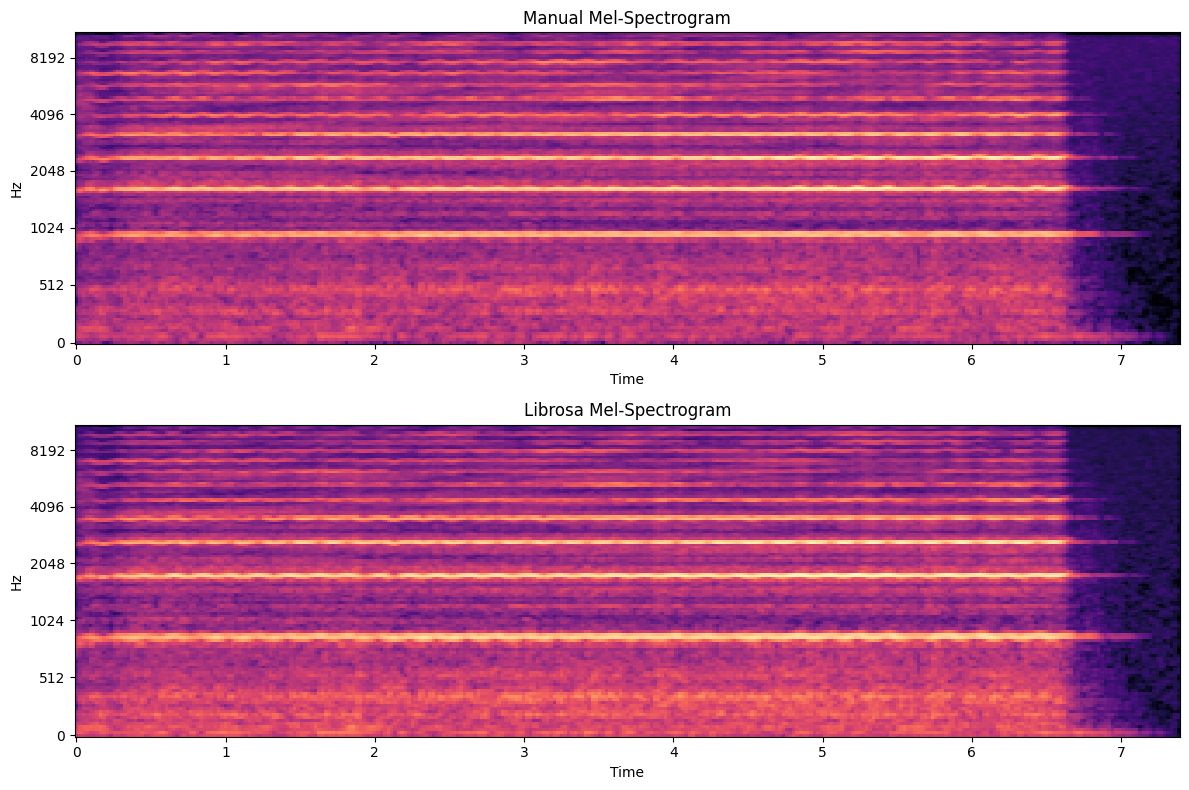

In [158]:
# Compare
are_close = np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-5)
print(f"Manual and librosa implementations match: {are_close}")

# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

librosa.display.specshow(
    librosa.power_to_db(mel_spec_manual, ref=np.max),
    sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax1
)
ax1.set_title('Manual Mel-Spectrogram')

librosa.display.specshow(
    librosa.power_to_db(mel_spec_librosa, ref=np.max),
    sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax2
)
ax2.set_title('Librosa Mel-Spectrogram')

plt.tight_layout()

plt.show();

Визуально разницы между двумя Mel-спектрограммами тяжело увидеть. <br> 
Можно сказать что Mel-спектрограммы практически идентичны.

### **3.7 Bonus: Try with torchaudio**
- Repeat using `torchaudio.transforms.MelSpectrogram`.
- Compare with your implementation.

In [159]:
# !pip install torch torchaudio

In [160]:
import torchaudio
import torch

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sr, n_fft=n_fft, hop_length=hop_length, n_mels=128
)
mel_spec_torch = mel_transform(torch.tensor(y)).numpy()

# Note: torchaudio uses different scaling, so direct comparison needs care
if mel_spec_torch.ndim == 3:
    mel_spec_torch = mel_spec_torch[0]

print(mel_spec_torch.shape)

(128, 319)


In [161]:
# Сравнение с ручной реализацией

are_close = np.allclose(mel_spec_manual, mel_spec_torch, atol=1e-5)
print(f"Manual and torchaudio implementations match: {are_close}")

Manual and torchaudio implementations match: False


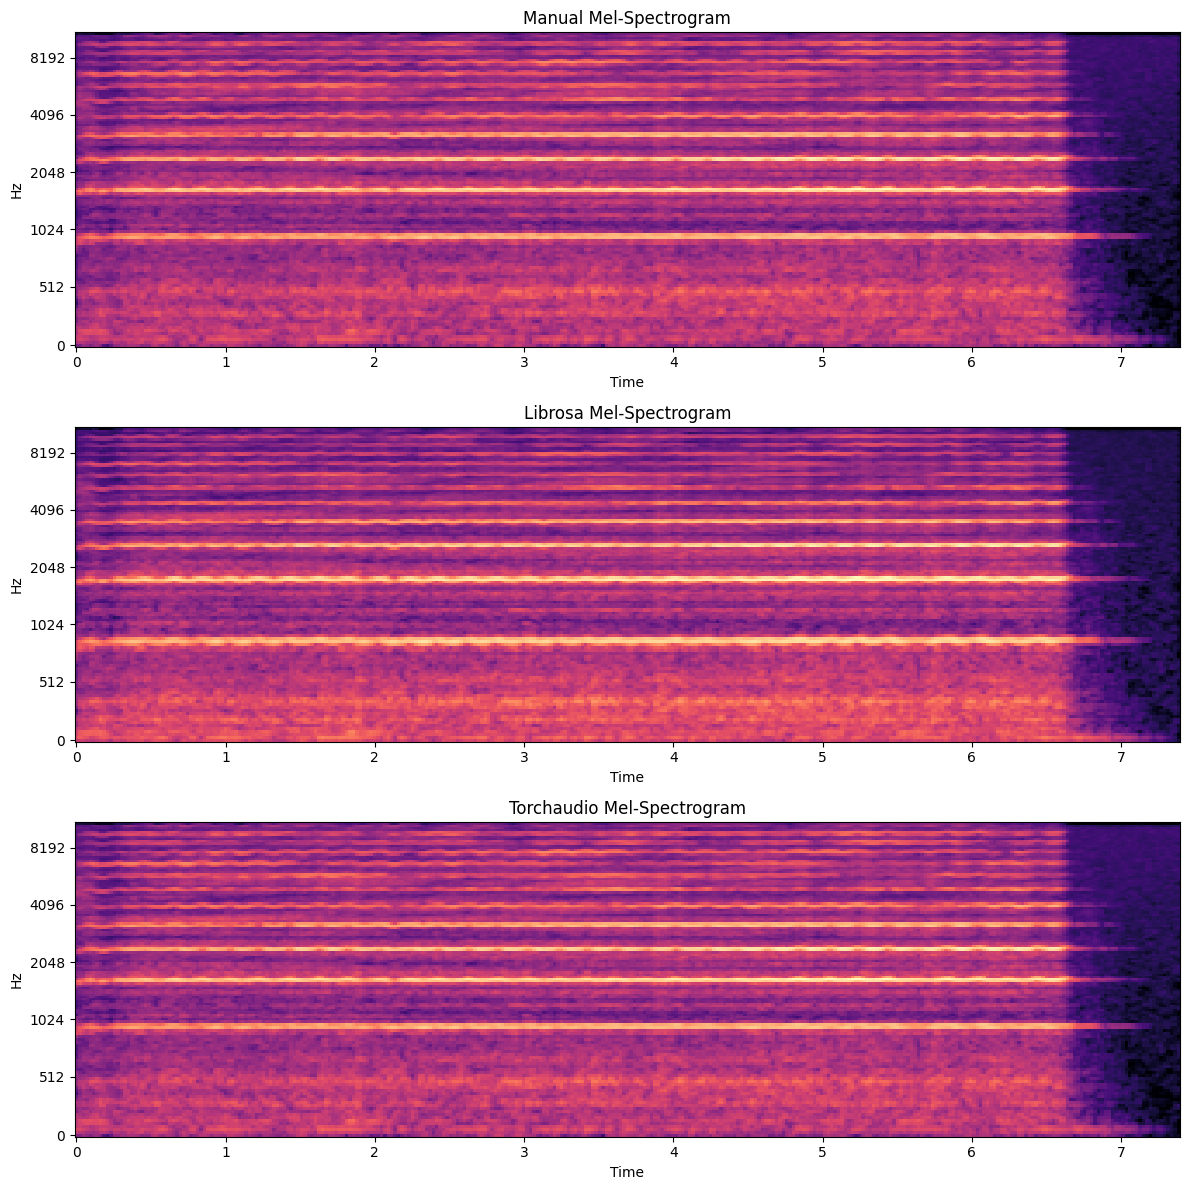

In [162]:
# Plot comparison
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

# Manual Mel-Spectrogram
librosa.display.specshow(
    librosa.power_to_db(mel_spec_manual, ref=np.max),
    sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax1
)
ax1.set_title('Manual Mel-Spectrogram')

# Librosa Mel-Spectrogram
librosa.display.specshow(
    librosa.power_to_db(mel_spec_librosa, ref=np.max),
    sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax2
)
ax2.set_title('Librosa Mel-Spectrogram')

# Torchaudio Mel-Spectrogram
librosa.display.specshow(
    librosa.power_to_db(mel_spec_torch, ref=np.max),
    sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax3
)
ax3.set_title('Torchaudio Mel-Spectrogram')

plt.tight_layout()

plt.show();

Можно сказать что Mel-спектрограммы практически идентичны.